In [3]:
from sklearn.datasets import load_iris


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline


iris = load_iris()
feature_names = ['sepal_length','sepal_width','petal_length','petal_width']


# 보다 편리한 데이타 Handling을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
irisDF['target'] = iris.target


In [4]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=0.6, min_samples=8, metric='euclidean') # euclidean: 대각선으로 거리재는 방식
dbscan_labels = dbscan.fit_predict(iris.data)


irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target


iris_result = irisDF.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)

# target  dbscan_cluster
# 0        0                49
#         -1                 1
# 1        1                46
#         -1                 4
# 2        1                42
#         -1                 8
# 
# 결과의 -1은 이상치.

target  dbscan_cluster
0        0                49
        -1                 1
1        1                46
        -1                 4
2        1                42
        -1                 8
Name: count, dtype: int64


In [5]:
### 클러스터 결과를 담은 DataFrame과 사이킷런의 Cluster 객체등을 인자로 받아 클러스터링 결과를 시각화하는 함수  
def visualize_cluster_plot(clusterobj, dataframe, label_name, iscenter=True):
    if iscenter :
        centers = clusterobj.cluster_centers_
       
    unique_labels = np.unique(dataframe[label_name].values)
    markers=['o', 's', '^', 'x', '*']
    isNoise=False


    for label in unique_labels:
        label_cluster = dataframe[dataframe[label_name]==label]
        if label == -1:
            cluster_legend = 'Noise'
            isNoise=True
        else :
            cluster_legend = 'Cluster '+str(label)
       
        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], s=70,\
                    edgecolor='k', marker=markers[label], label=cluster_legend)
       
        if iscenter:
            center_x_y = centers[label]
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=250, color='white',
                        alpha=0.9, edgecolor='k', marker=markers[label])
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k',\
                        edgecolor='k', marker='$%d$' % label)
    if isNoise:
        legend_loc='upper center'
    else: legend_loc='upper right'
   
    plt.legend(loc=legend_loc)
    plt.show()


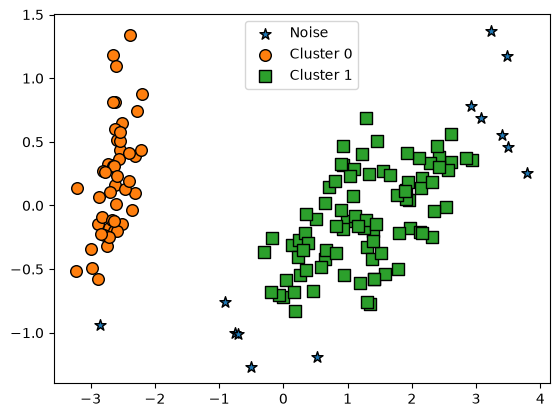

In [ ]:
from sklearn.decomposition import PCA
# 2차원으로 시각화하기 위해 PCA n_componets=2로 피처 데이터 세트 변환
pca = PCA(n_components=2, random_state=0)   
pca_transformed = pca.fit_transform(iris.data)  # 4차원->2차원
# visualize_cluster_2d( ) 함수는 ftr1, ftr2 컬럼을 좌표에 표현하므로 PCA 변환값을 해당 컬럼으로 생성
irisDF['ftr1'] = pca_transformed[:,0]
irisDF['ftr2'] = pca_transformed[:,1]


visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)



target  dbscan_cluster
0        0                50
1        1                50
2        1                47
        -1                 3
Name: count, dtype: int64


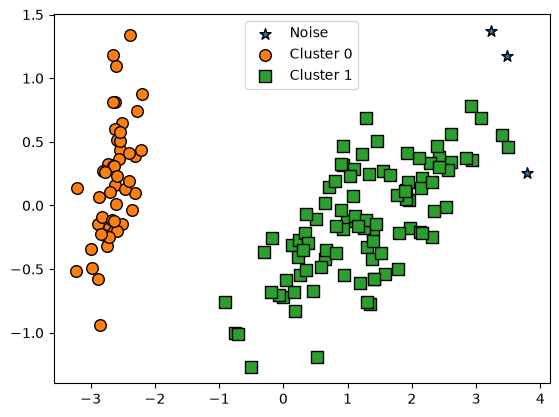

In [ ]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=0.8, min_samples=8, metric='euclidean') 
    # eps: 반경(엡실론), min_samples: 반경 내에 포함된 데이터 개수
dbscan_labels = dbscan.fit_predict(iris.data)


irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target


iris_result = irisDF.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)


visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)


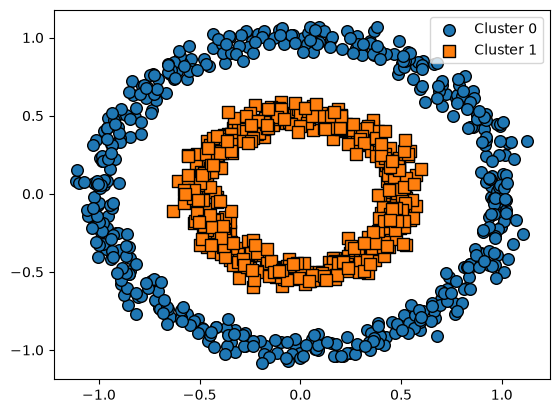

In [9]:
from sklearn.datasets import make_circles


X, y = make_circles(n_samples=1000, shuffle=True, noise=0.05, random_state=0, factor=0.5)
clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y


visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)

c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


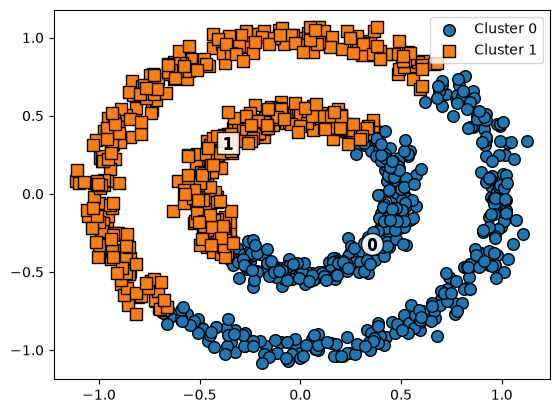

In [11]:
# KMeans로 make_circles( ) 데이터 셋을 클러스터링 수행.
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=2, max_iter=1000, random_state=0)
kmeans_labels = kmeans.fit_predict(X)
clusterDF['kmeans_cluster'] = kmeans_labels


visualize_cluster_plot(kmeans, clusterDF, 'kmeans_cluster', iscenter=True)

c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


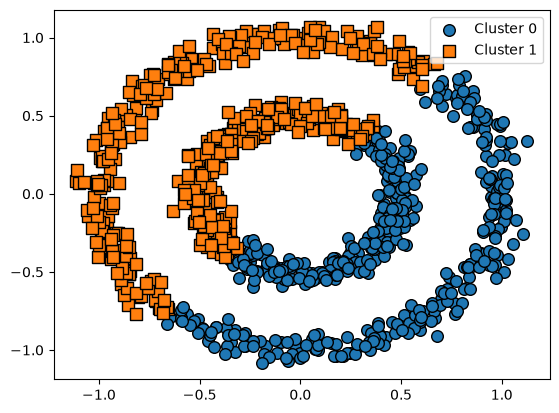

In [12]:
# GMM으로 make_circles( ) 데이터 셋을 클러스터링 수행.
from sklearn.mixture import GaussianMixture


gmm = GaussianMixture(n_components=2, random_state=0)
gmm_label = gmm.fit(X).predict(X)
clusterDF['gmm_cluster'] = gmm_label


visualize_cluster_plot(gmm, clusterDF, 'gmm_cluster', iscenter=False)


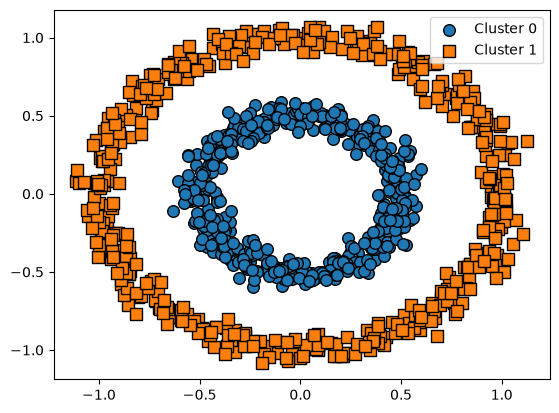

In [ ]:
# DBSCAN으로 make_circles( ) 데이터 셋을 클러스터링 수행.
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=0.2, min_samples=10, metric='euclidean')
dbscan_labels = dbscan.fit_predict(X)
clusterDF['dbscan_cluster'] = dbscan_labels


visualize_cluster_plot(dbscan, clusterDF, 'dbscan_cluster', iscenter=False)

In [14]:
# 군집화 목적: 레이블 추정할 때 사용. (답 찾을 때)
# 마케팅에 많이 사용: 고객 분리, 고객 분류 예. 특정 그룹 안의 데이터를 살펴봄. 많이 산 상품을 좋아하니 new data에도 추천.